# Pair Classification & Calibration

**Goal.** Learn a pairwise JD↔CV classifier that outputs calibrated probabilities for a fixed **Pass/Review** decision and supports explanation.


In [23]:
RESUMES_CSV = "data/processed/resumes_clean.csv"
JDS_CSV     = "data/processed/jd_clean.csv"
PAIRS_CSV   = "data/raw/gold_pairs_adzuna.csv"
REPORTS_DIR = "reports"
FIGURES_DIR = "figures"
ARTIFACTS_DIR = "artifacts"

## Features & Model
- **Input:** concatenated pair — `"[JD] ... [RESUME] ..."` → **TF-IDF**.
- **Classifier:** **Logistic Regression (L2)**, linear and sparse-friendly.
- **Calibration:** isotonic (preferred) or Platt/sigmoid on the **validation split*.


In [30]:
import pandas as pd, numpy as np, os, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_recall_fscore_support, precision_recall_curve,
brier_score_loss, confusion_matrix)
from sklearn.calibration import CalibratedClassifierCV
from pathlib import Path
import json, joblib

os.makedirs("reports", exist_ok=True)
os.makedirs("figures", exist_ok=True)

def must_exist(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"File not found: {path}. Please set the correct path in the first cell.")
    return path

resumes = pd.read_csv(must_exist(RESUMES_CSV))
jds     = pd.read_csv(must_exist(JDS_CSV))
pairs   = pd.read_csv(must_exist(PAIRS_CSV))

In [11]:
# Richer JD per title
jd_lookup = (jds.dropna(subset=["job_title", "jd_text"])
             .groupby("job_title")["jd_text"]
             .apply(lambda s: " [SEP] ".join(sorted(s.astype(str), key=len, reverse=True)[:3]))
             .to_dict())

text_col = "clean_text_redacted" if "clean_text_redacted" in resumes.columns else "clean_text"
res_lookup = dict(zip(resumes["row_id"].astype(str), resumes[text_col].astype(str)))

pairs_work = pairs.dropna(subset=["row_id", "job_title", "label"]).copy()
pairs_work["row_id"] = pairs_work["row_id"].astype(str)
pairs_work["text"] = pairs_work.apply(lambda r: res_lookup.get(r["row_id"], "") + " [SEP] " + jd_lookup.get(str(r["job_title"]), ""), axis=1)

vec = TfidfVectorizer(min_df=2)
X = vec.fit_transform(pairs_work["text"].astype(str).tolist())
y = pairs_work["label"].astype(int).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=300).fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]

#### Base Metrics

In [13]:
pred = (proba >= 0.5).astype(int)
base = {
    "roc_auc": float(roc_auc_score(y_test, proba)),
    "pr_auc": float(average_precision_score(y_test, proba)),
    "f1": float(f1_score(y_test, pred)),
    "precision": float(precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)[0]),
    "recall": float(precision_recall_fscore_support(y_test, pred, average="binary", zero_division=0)[1]),
    "brier": float(brier_score_loss(y_test, proba)),
}
pd.Series(base).to_csv("reports/classification_base_metrics.csv")
base

{'roc_auc': 0.8233757057144273,
 'pr_auc': 0.6142085477149538,
 'f1': 0.49933598937583,
 'precision': 0.6619718309859155,
 'recall': 0.40085287846481876,
 'brier': 0.1493287836589138}

In [15]:
# Two operating points (screening vs shortlisting) + PR curve
thr = np.linspace(0.01, 0.99, 99) # thresholds
rows = []
for t in thr:
    p = (proba >= t).astype(int)
    P, R, F1, _ = precision_recall_fscore_support(y_test, p, average="binary", zero_division=0)
    beta = 2
    F2 = (1 + beta ** 2) * P * R / (beta ** 2 * P + R) if (beta ** 2 * P + R) > 0 else 0.0
    rows.append({"threshold": t, "precision": P, "recall": R, "f1": F1, "f2": F2})
grid = pd.DataFrame(rows)

screen = grid[grid["recall"] >= 0.80]
if screen.empty:
    screen = grid[grid["recall"] >= 0.70]
screen = screen.sort_values(["f2", "precision"], ascending=False).iloc[0]

short = grid[grid["precision"] >= 0.75]
if short.empty:
    short = grid[grid["precision"] >= 0.70]
short = short.sort_values(["recall", "f1"], ascending=False).iloc[0]

def cm_at(t):
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    return dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))

op_table = pd.DataFrame([
    {"mode": "screening", **screen.to_dict(), **{f"cm_{k}": v for k, v in cm_at(float(screen["threshold"])).items()}},
    {"mode": "shortlist", **short.to_dict(), **{f"cm_{k}": v for k, v in cm_at(float(short["threshold"])).items()}},
])
op_table.to_csv(REPORTS_DIR + "/operating_points.csv", index=False)
op_table

,mode,threshold,precision,recall,f1,f2,cm_tn,cm_fp,cm_fn,cm_tp
0,screening,0.17,0.438342,0.901919,0.589958,0.744456,662,542,46,423
1,shortlist,0.73,0.750000,0.063966,0.117878,0.078288,1194,10,439,30


#### Finding out the Operating Threshold

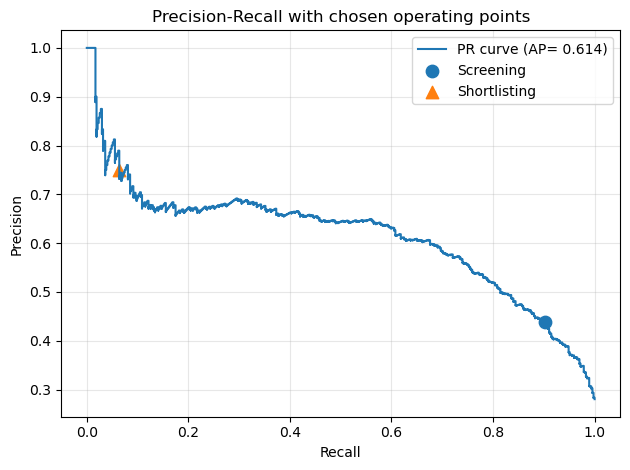

In [17]:
prec, rec, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
plt.figure()
plt.step(rec, prec, where="post", label=f"PR curve (AP={ap: .3f})")
plt.scatter([screen["recall"]], [screen["precision"]], s=80, marker="o", label="Screening")
plt.scatter([short["recall"]], [short["precision"]], s=80, marker="^", label="Shortlisting")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Precision-Recall with chosen operating points")
plt.tight_layout()
plt.savefig(FIGURES_DIR + "/pr_curve_operating_points.png", dpi=150)
plt.show()

#### Calibration: Brier & reliability curves

In [19]:
X_tr2, X_cal, y_tr2, y_cal = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
base_m = LogisticRegression(max_iter=300).fit(X_tr2, y_tr2)
sig = CalibratedClassifierCV(base_m, method="sigmoid", cv="prefit").fit(X_cal, y_cal)
iso = CalibratedClassifierCV(base_m, method="isotonic", cv="prefit").fit(X_cal, y_cal)
proba_sig = sig.predict_proba(X_test)[:, 1]
proba_iso = iso.predict_proba(X_test)[:, 1]

print("Brier raw:", brier_score_loss(y_test, proba))
print("Brier sigmoid:", brier_score_loss(y_test, proba_sig))
print("Brier isotonic:", brier_score_loss(y_test, proba_iso))

Brier raw: 0.1493287836589138
Brier sigmoid: 0.14856411418637644
Brier isotonic: 0.1489557104228232


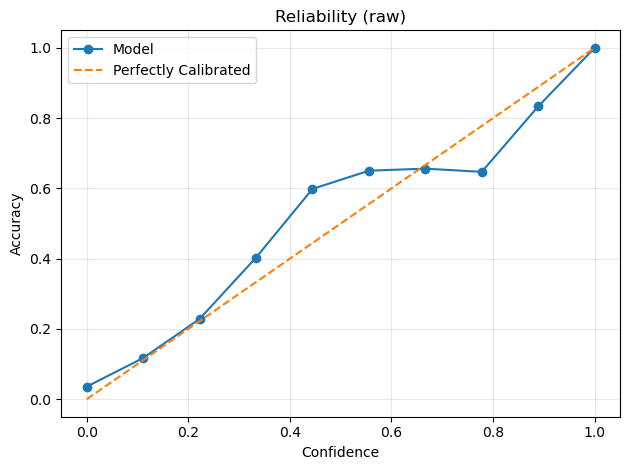

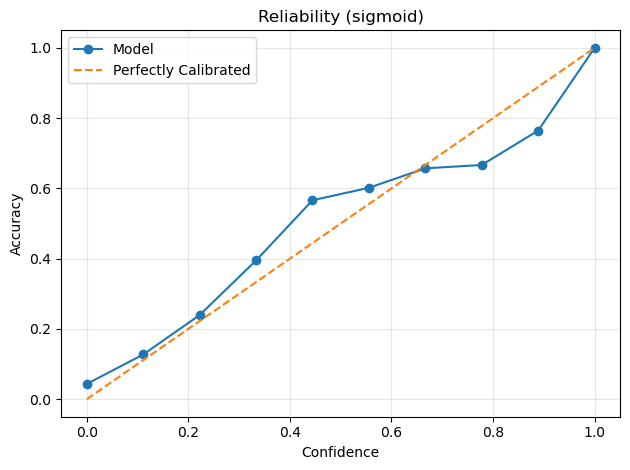

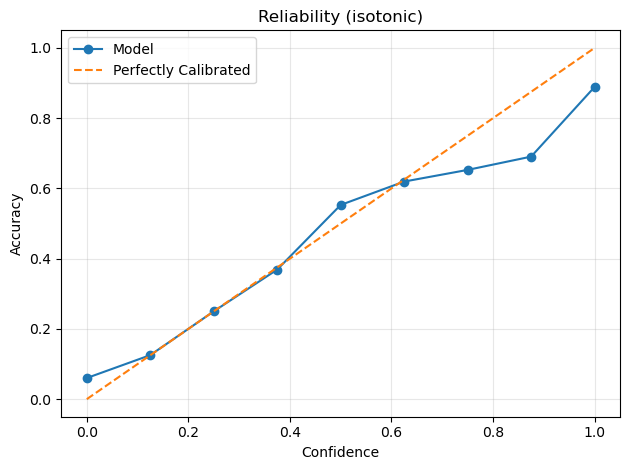

Saved classification metrics + figures to reports/


In [21]:
def reliability(y_true, y_prob, bins=10, title="", out=""):
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    df["bin"] = np.clip((df["p"] * bins).astype(int), 0, bins - 1)
    grp = df.groupby("bin").agg(confidence=("p", "mean"), accuracy=("y", "mean"), count=("y", "size"))
    plt.figure()
    plt.plot(np.linspace(0, 1, len(grp)), grp["accuracy"].values, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly Calibrated")
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(out, dpi=150)
    plt.show()
    return grp

rel_raw = reliability(y_test, proba, title="Reliability (raw)", out=FIGURES_DIR + "/reliability_raw.png")
rel_sig = reliability(y_test, proba_sig, title="Reliability (sigmoid)", out=FIGURES_DIR + "/reliability_sigmoid.png")
rel_iso = reliability(y_test, proba_iso, title="Reliability (isotonic)", out=FIGURES_DIR + "/reliability_isotonic.png")

rel_raw.to_csv(REPORTS_DIR + "/reliability_bins_raw.csv")
rel_sig.to_csv(REPORTS_DIR + "/reliability_bins_sigmoid.csv")
rel_iso.to_csv(REPORTS_DIR + "/reliability_bins_isotonic.csv")
print("Saved classification metrics + figures to reports/")

#### What the Plots Show
- **PR curve with points:** Average Precision and the chosen screening/shortlisting cutoffs.
- **Reliability curves:** Raw vs. isotonic vs. sigmoid. Calibrated curves track the diagonal better ⇒ reported probabilities are meaningful.

#### Saving Artifacts

In [26]:
os.makedirs("artifacts", exist_ok=True)

In [32]:
# Vectorizer + Classifier
joblib.dump(vec, "artifacts/cls_tfidf.joblib")
joblib.dump(clf, "artifacts/cls_lr.joblib")

# Calibrator
try:
    joblib.dump(iso, "artifacts/cls_cal_isotonic.joblib")
except Exception:
    pass

# Thresholds chosen from PR sweep
with open("artifacts/thresholds.json", "w") as f:
    json.dump({
        "scrrening_threshold": float(screen["threshold"]),
        "shortlist_threshold": float(short["threshold"])
    }, f)

print("Saved Artifacts")

Saved Artifacts
